In [3]:

import pandas as pd
import json
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'}

#из файла excel берем столбец ИНН-ов
res = pd.read_excel('rsmp_06.02.2025.xlsx', header=2)
print(res.columns)


/Users/julia/Analythics/Analythics/.venv/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Index(['№ п/п', 'Наименование / ФИО', 'Тип субъекта', 'Категория', 'ОГРН',
       'ИНН', 'Основной вид деятельности', 'Регион', 'Район', 'Город',
       'Населенный пункт', 'Вновь созданный', 'Дата включения в реестр',
       'Дата исключения из реестра', 'Телефон', 'E-mail', 'WWW',
       'Наличие лицензий', 'Наличие заключенных договоров, контрактов',
       'Производство инновационной, высокотехнологичной продукции',
       'Участие в программах партнерства', 'Является социальным предприятием',
       'Среднесписочная численность работников за предшествующий календарный год'],
      dtype='object')


In [4]:
res_inn = res["ИНН"]
#посмотрим, сколько ИНН-ов у нас всего: оказалось очень много, смотреть будем не все
res_inn.shape[0]

645344

In [10]:
import json
import requests

/Users/julia/PyCharmMiscProject/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [11]:
result = []
#проходимся по столбцу ИНН-ов и для каждого с сайта берем json, из которого достаем id, называем его org_id
#потом по org_id получаем еще один json, из него берем "correction", из которого и достаем данные для EBITDA
EBITDA22 = 1
EBITDA23 = 0
EBITDA_ratio = 0

#В этом интервале довольно много данных для анализа(если все смотреть, очень долго получается)
for i in range(5600, 6500):
    flag1 = 0
    flag2 = 0
    r_by_inn = requests.get(f'http://bo.nalog.ru/advanced-search/organizations/search?query={res_inn[i]}&page=0&size=20', headers=headers).json()


    if r_by_inn["content"]:
        org_id = r_by_inn["content"][0]["id"]

        r_by_id = requests.get(f'https://bo.nalog.ru/nbo/organizations/{org_id}/bfo/', headers=headers).json()

        r_by_id = pd.DataFrame(r_by_id)

        for j in range(r_by_id['correction'].shape[0]):
            r_new = pd.DataFrame(r_by_id['correction'][j])
            dateYear = r_new["datePresent"]["id"][0:4]

            #если указан 2023 год, значит, это отчетность за 2022й
            if dateYear == "2023" and  "current2400" in r_new["financialResult"]:
                flag1 = 1
                #Чистая прибыль должна быть указана, иначе зачем нам лишний ноль на гистограмме
                v1 = r_new["financialResult"]["current2400"]
                #Остальные поля проверяем: если не заполнено, приравниваем к нулю
                if "current2350" in r_new["financialResult"]:
                    v2 = r_new["financialResult"]["current2350"]
                else:
                    v2 = 0
                if "current2220" in r_new["financialResult"]:
                    v3 = r_new["financialResult"]["current2220"]
                else:
                    v3 = 0
                if "current2410" in r_new["financialResult"]:
                    v4 = r_new["financialResult"]["current2410"]
                else:
                    v4 = 0
                EBITDA22 = v1 + v2 + v3 + v4
            if dateYear == "2024" and  "current2400" in r_new["financialResult"]:

                flag2 = 1
                v1 = r_new["financialResult"]["current2400"]
                if "current2350" in r_new["financialResult"]:
                    v2 = r_new["financialResult"]["current2350"]
                else:
                    v2 = 0
                if "current2220" in r_new["financialResult"]:
                    v3 = r_new["financialResult"]["current2220"]
                else:
                    v3 = 0
                if "current2410" in r_new["financialResult"]:
                    v4 = r_new["financialResult"]["current2410"]
                else:
                    v4 = 0
                EBITDA23 = v1 + v2 + v3 + v4
        if EBITDA22 != 0:
            EBITDA_ratio = EBITDA23 / EBITDA22
        if flag1 == 1 and flag2 == 1:
            result.append(EBITDA_ratio)


In [12]:
print(result)

[0.9990077431472261, 0.40271493212669685, 3.846765233740706, -9.637130801687764, 1.375401560348784, 1.0666302566903332, 1.0666302566903332, 0.5672116756282234, 1.555980196299835, 0.972448153983733, 0.17443540358257667, 0.43267520591952197, 0.7789473684210526, 1.9929618314706679, -1026.4, 0.8260556973912023, 4.871027167668481, 0.2455069515089861, 0.7368421052631579, 0.7368421052631579, 1.010598084460008, 20.26466226237023, 1.4973029685366352, 0.6272189349112426, 3.244996396296502, -0.34982007784387165, 0.8977043613596972, 3.9854103343465046, 5.515151515151516, 0.0854033509793854, 1.6065063518778964, -58.12285168682368, 0.5968481598072364, -4.774381368267831, 2.426751592356688, 1.2043498263923023, -27.26615969581749, 3.4285714285714284, 1.013134328358209, 1.3181818181818181, 0.8723502837947411, -0.3548387096774194, 0.6000291046676611, 0.6025106147314011, -1.9, -0.06432445178024052, -542.0912863070539, 0.7371468192061016, 0.6889723455104131, 1.1538461538461537, -0.5088897668905571, -0.508

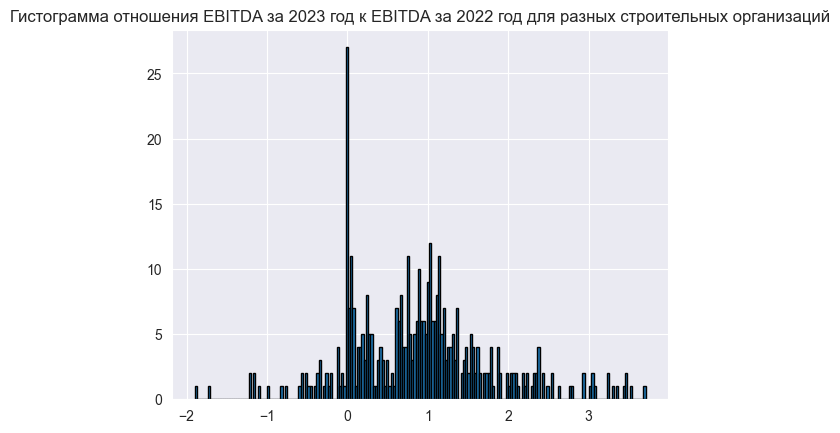

In [13]:
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import matplotlib.pyplot as plt

# Рассчитываем межквартильный размах (IQR)
q1 = np.percentile(result, 25)  # Первый квартиль (25%)
q3 = np.percentile(result, 75)  # Третий квартиль (75%)
iqr = q3 - q1  # Межквартильный размах

# Границы выбросов
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

#Уберем выбросы, чтобы не мешали
filtered_data = [x for x in result if lower_bound <= x <= upper_bound]
plt.hist(filtered_data, bins=200, edgecolor='black')
plt.title("Гистограмма отношения EBITDA за 2023 год к EBITDA за 2022 год для разных строительных организаций")
plt.show()
